# Code for the paper "Scalable vertex-guided filtrations identify structurally relevant genes in cancer networks"

The provided notebook includes all necessary procedures to reproduce the experiments and results presented in the manuscript.

To ensure full reproducibility, the entire project must be downloaded and executed locally. The code reads, generates, and stores multiple files, which are organized within a predefined folder structure (originally developed in a Windows environment).


In [1]:
!pip install gudhi
import networkx as nx
import numpy as np
import gudhi as gd
import matplotlib.pyplot as plt
import os
import pandas as pd
from glob import glob
import gc
from IPython import display
import shutil
from pathlib import Path
#There are some FutureWarnings from Gudhi that we can ignore for cleaner output
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

## Main Configurations

In [2]:
MAX_DIM = 4
FIXED_SEED = 42

# You can comment out the measures you don't want to compute, or uncomment all. The main functions deal with the measures in a loop for each network (CCN)
CENTRALITY_MEASURES = [
    'degree',
    'betweenness',
    'eigenvector',
]

## Read the CCNs
Open the 3 CCNs networks and make sure the use only the Largest Connected Component

In [3]:
CCNs={}

CCNs['CO'] = nx.read_edgelist('1 - input CCNs/Consensus CO', create_using=nx.Graph(), nodetype=str)
lcc = max(nx.connected_components(CCNs['CO']), key=len)
CCNs['CO'] = CCNs['CO'].subgraph(lcc).copy()

CCNs['DN'] = nx.read_edgelist('1 - input CCNs/Consensus DN', create_using=nx.Graph(), nodetype=str)
lcc = max(nx.connected_components(CCNs['DN']), key=len)
CCNs['DN'] = CCNs['DN'].subgraph(lcc).copy()

CCNs['PCD'] = nx.read_edgelist('1 - input CCNs/Consensus PCD', create_using=nx.Graph(), nodetype=str)
lcc = max(nx.connected_components(CCNs['PCD']), key=len)
CCNs['PCD'] = CCNs['PCD'].subgraph(lcc).copy()

print(f"Number of nodes in CO: {CCNs['CO'].number_of_nodes()} and edges: {CCNs['CO'].number_of_edges()}")
print(f"Number of nodes in DN: {CCNs['DN'].number_of_nodes()} and edges: {CCNs['DN'].number_of_edges()}")
print(f"Number of nodes in PCD: {CCNs['PCD'].number_of_nodes()} and edges: {CCNs['PCD'].number_of_edges()}")

Number of nodes in CO: 162 and edges: 1297
Number of nodes in DN: 233 and edges: 4616
Number of nodes in PCD: 170 and edges: 1840


## Helper Functions
Functions to choose the centrality, plot the network and to plot the Persistent Homology Barcodes

In [4]:
def plot_network_visualization(G,output_path, name=None,show=False):
    plt.figure(figsize=(10, 10))
    pos = nx.kamada_kawai_layout(G)
    nx.draw(G, pos, with_labels=False, node_size=40, width=0.1, node_color='blue')
    if name:
        plt.title(name)    
    
    plt.savefig(output_path, dpi=300, bbox_inches='tight')

    if show:
        plt.show()
    plt.close()

def get_centrality(G, measure='degree'):
    if measure == 'degree':
        return dict(G.degree())
    elif measure == 'betweenness':
        return nx.betweenness_centrality(G)
    elif measure == 'eigenvector':
        return nx.eigenvector_centrality(G)
    else:
        raise ValueError("Unknown centrality measure")

def plot_barcode_and_diagram(output_path, persistence,  betti_numbers, title_prefix="", filtration_name="", max_dim=MAX_DIM, show=False):

    beta = "β"

    # Process betti_numbers to get the dimension_resume string, ensuring numerical sort and integer comparison
    formatted_betti_parts = []
    # Sort items numerically based on the dimension number extracted from the string key
    for dim_key, count in sorted(betti_numbers.items(), key=lambda item: int(item[0].split(' ')[1]) if item[0].startswith('Betti ') else -1):
        try:
            # Extract the integer dimension from the string key, e.g., "Betti 0" -> 0
            dim_val = int(dim_key.split(' ')[1])
            if dim_val <= max_dim:
                formatted_betti_parts.append(f'{beta}_{dim_val}: {count}')
        except (ValueError, IndexError):
            # Fallback if the key format is not as expected, e.g., not "Betti X"
            pass

    dimension_resume = ' | '.join(formatted_betti_parts)

    info_block = (
        f"Betti Numbers: {dimension_resume}\n"
        f"Filtration: {filtration_name} | Max Dimension: {max_dim}"
    )

    ordered_persistence = sorted(persistence, key=lambda pair: (pair[0], pair[1][0]))

    fig, axs = plt.subplots(1, 2, figsize=(14, 6))

    # BARCODE with info
    gd.plot_persistence_barcode(ordered_persistence, axes=axs[0], legend=True)
    axs[0].set_title(f'Barcode de Persistência\n{title_prefix}\n{info_block}', fontsize=10)

    # DIAGRAM with info
    gd.plot_persistence_diagram(ordered_persistence, axes=axs[1], legend=True)
    axs[1].set_title(f'Diagrama de Persistência\n{title_prefix}\n{info_block}', fontsize=10)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')

    if show:
         plt.show()
    
    
    plt.close()
    print(f" TDA saved info: {os.path.basename(output_path)}")
    

# The VFB Function
The heart of the analysis. This function calculate the VFB filtration for a given Network and Measure

In [5]:
def compute_tda(G, vertex_function_data, max_dim, filtration_name="Centrality"):
    """ Returns a dictionary with Betti numbers and the persistence (for plotting). """

    # Nodes
    if G.number_of_nodes() < 2 or not vertex_function_data:
        return None, None

    node_map = {node: i for i, node in enumerate(G.nodes())}
    st = gd.SimplexTree()
    G_nodes = set(G.nodes())

    valid_vertex_values = [v for n, v in vertex_function_data.items() if n in G_nodes]
    if not valid_vertex_values:
        return None, None

    for node, V in vertex_function_data.items():
        if node in G_nodes:
            node_id = node_map[node]
            filtration_value = V # ALTERAÇÃO PARA COMEÇAR CRESCENDO
            st.insert([node_id], filtration_value)

    # Edges
    for u, v in G.edges():
        u_id = node_map.get(u)
        v_id = node_map.get(v)

        if u_id is not None and v_id is not None:
            V_u = vertex_function_data.get(u, 0.0)
            V_v = vertex_function_data.get(v, 0.0)

            # For sublevel filtration, an edge enters when *both* its endpoints have entered.
            # This happens when the filtration value reaches max(V_u, V_v).
            filtration_value = max(V_u, V_v)
            st.insert([u_id, v_id], filtration_value)

    st.expansion(max_dim)
    persistence = st.persistence()

    # Betti
    dimensionsLen = {}
    for dim, (birth, death) in persistence:
        dimensionsLen[dim] = dimensionsLen.get(dim, 0) + 1
    full_cycle_vector = [dimensionsLen.get(dim, 0) for dim in range(max_dim + 1)]

    tda_metrics_result = {
        'Nodes': G.number_of_nodes(),
        'Edges': G.number_of_edges(),
        'Filtration': filtration_name
    }
    for dim in range(max_dim + 1):
        tda_metrics_result[f'Betti {dim}'] = full_cycle_vector[dim]

    return tda_metrics_result, persistence



# Main Code
* We select a CCN, compute the VGF, and generate the corresponding figures and tables.<br>

* Additionally, we apply a systematic node removal procedure to emulate the effect of gene knockdown within the network, allowing us to assess the structural impact of individual gene perturbations. For each removal, figures and table are also saved. <br>

* The required directories are dynamically created during execution, and all intermediate and final outputs are automatically saved within this structure.Therefore, the execution environment must grant write permissions to allow file and directory creation.

* We display the network plot and the corresponding barcode/persistence diagrams for the original network, along with their associated topological measures, to facilitate visualization and interpretation.
* * For the networks obtained through systematic node removal, the corresponding plots are generated and saved to disk but are not displayed during execution in order to avoid visual clutter and excessive output.


Measure: DEGREE
Ranking saved: ranking_degree.csv (Top 162 genes)
 TOP 50: ['EP300', 'HDAC1', 'CREBBP', 'HDAC2', 'RBBP4', 'RBBP7', 'HDAC3', 'WDR5', 'ACTB', 'KAT2B', 'ACTL6A', 'SMARCA4', 'TRRAP', 'KAT2A', 'KDM1A', 'RELA', 'SMARCC2', 'SMARCC1', 'EZH2', 'REST', 'NCOR1', 'SMARCE1', 'MTA2', 'SMARCD3', 'ATF2', 'SMARCA2', 'CHD3', 'CHD4', 'ASH2L', 'KAT5', 'SMARCB1', 'MBD3', 'EED', 'TAF9', 'TADA3', 'RBBP5', 'RUVBL1', 'RUVBL2', 'MTA1', 'MTA3', 'RCOR1', 'ARID1A', 'SUZ12', 'PRMT1', 'PRMT5', 'TADA2B', 'CLOCK', 'CCND1', 'NCOA1', 'EPC1']


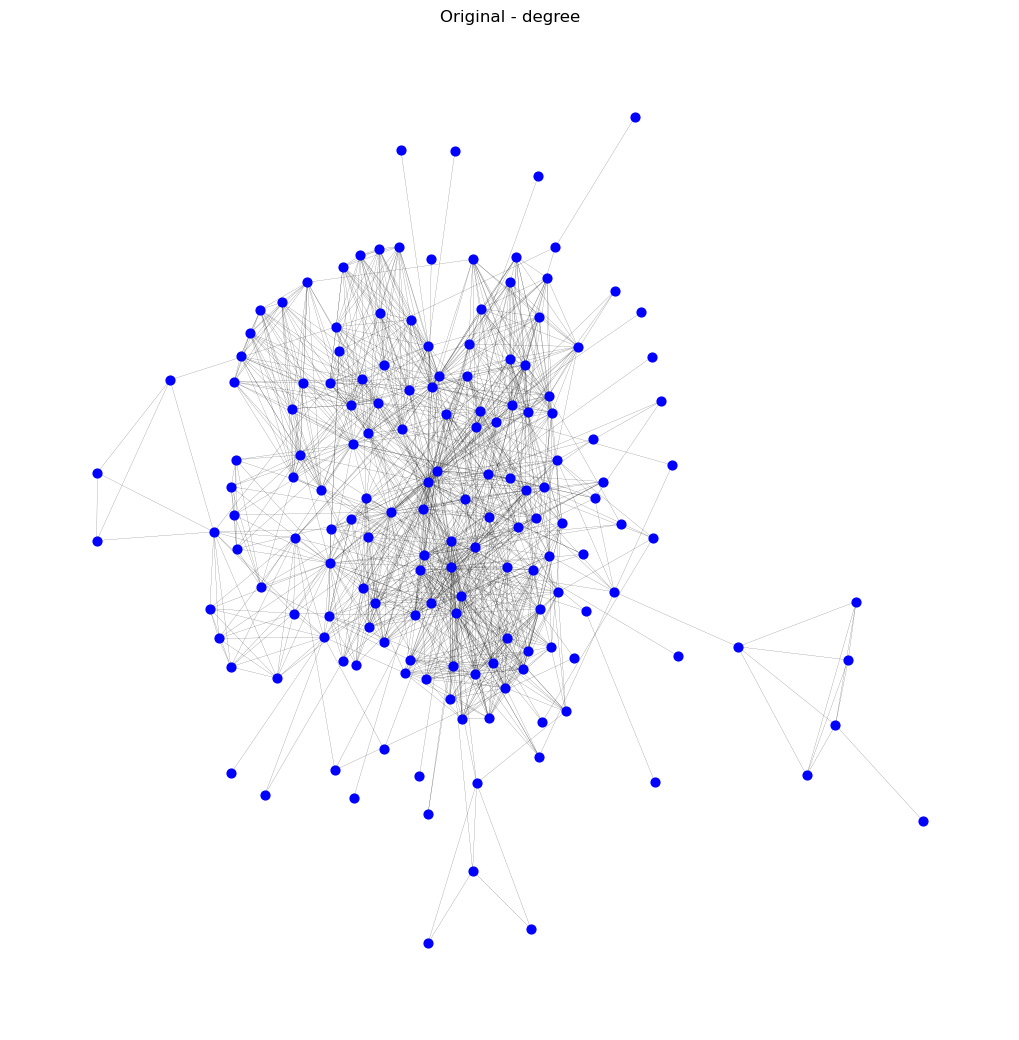

c:\Users\ragna\anaconda3\Lib\site-packages\gudhi\persistence_graphical_tools.py:105: UserWarning: This function is not available.
ModuleNotFoundError: No module named 'matplotlib'.
  warnings.warn(f"This function is not available.\nModuleNotFoundError: No module named '{import_error.name}'.")


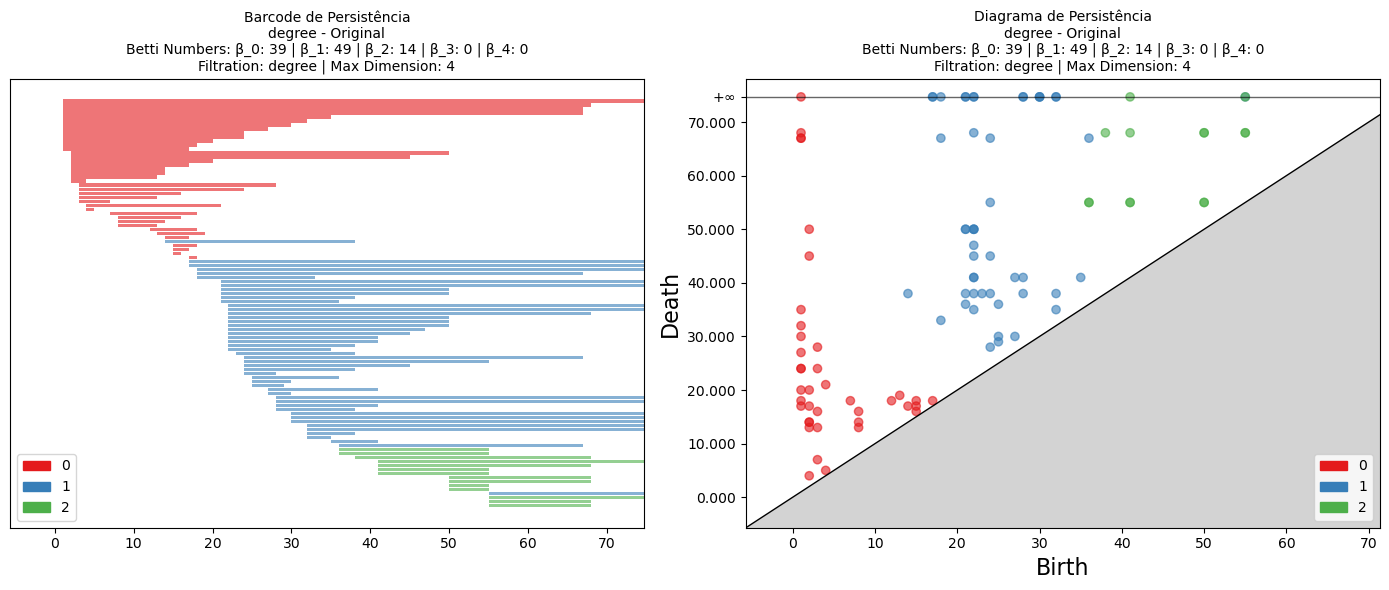

 TDA saved info: barcode_original_degree.png
 Original CNN: original_degree.png
 Original TDA: barcode_original_degree.png

Starting systematic node removal and TDA computation for measure: DEGREE
  node 1/162: SETD1A
Network plot saved: without_SETD1A_degree.png
 TDA saved info: barcode_without_SETD1A_degree.png
  TDA saved: barcode_without_SETD1A_degree.png
  node 2/162: ASH2L
Network plot saved: without_ASH2L_degree.png
 TDA saved info: barcode_without_ASH2L_degree.png
  TDA saved: barcode_without_ASH2L_degree.png
  node 3/162: EP300
Network plot saved: without_EP300_degree.png
 TDA saved info: barcode_without_EP300_degree.png
  TDA saved: barcode_without_EP300_degree.png
  node 4/162: HDAC1
Network plot saved: without_HDAC1_degree.png
 TDA saved info: barcode_without_HDAC1_degree.png
  TDA saved: barcode_without_HDAC1_degree.png
  node 5/162: KAT2B
Network plot saved: without_KAT2B_degree.png
 TDA saved info: barcode_without_KAT2B_degree.png
  TDA saved: barcode_without_KAT2B_degre

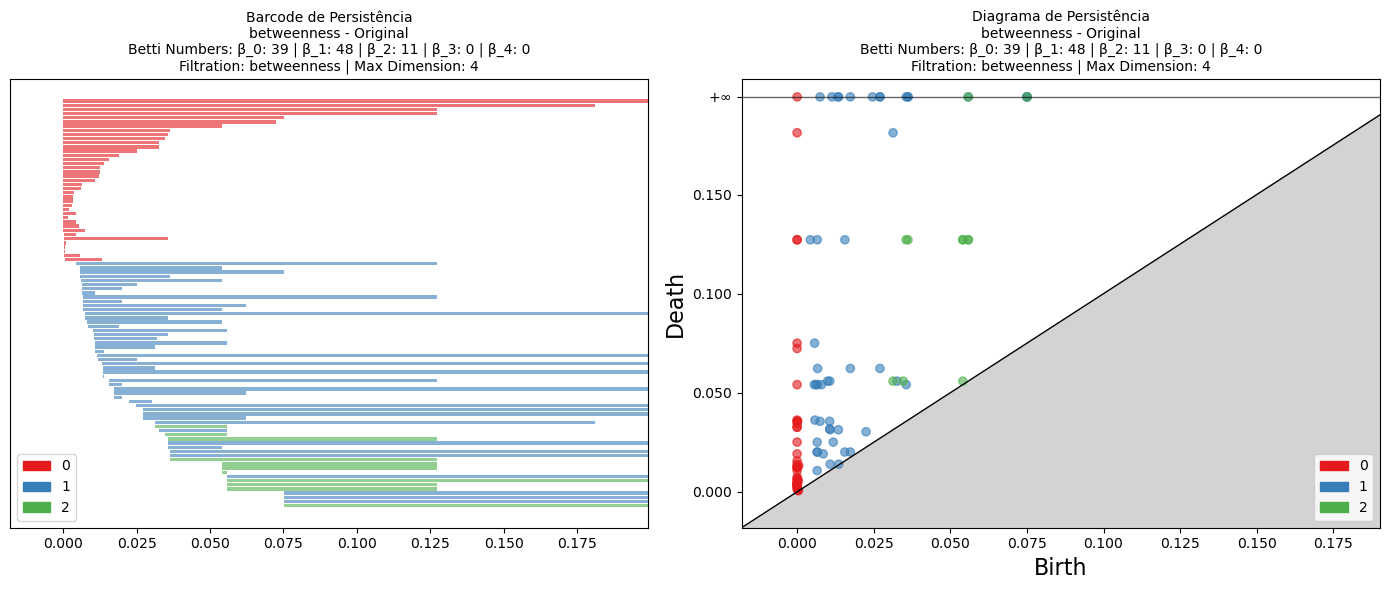

 TDA saved info: barcode_original_betweenness.png
 Original CNN: original_betweenness.png
 Original TDA: barcode_original_betweenness.png

Starting systematic node removal and TDA computation for measure: BETWEENNESS
  node 1/162: SETD1A
Network plot saved: without_SETD1A_betweenness.png
 TDA saved info: barcode_without_SETD1A_betweenness.png
  TDA saved: barcode_without_SETD1A_betweenness.png
  node 2/162: ASH2L
Network plot saved: without_ASH2L_betweenness.png
 TDA saved info: barcode_without_ASH2L_betweenness.png
  TDA saved: barcode_without_ASH2L_betweenness.png
  node 3/162: EP300
Network plot saved: without_EP300_betweenness.png
 TDA saved info: barcode_without_EP300_betweenness.png
  TDA saved: barcode_without_EP300_betweenness.png
  node 4/162: HDAC1
Network plot saved: without_HDAC1_betweenness.png
 TDA saved info: barcode_without_HDAC1_betweenness.png
  TDA saved: barcode_without_HDAC1_betweenness.png
  node 5/162: KAT2B
Network plot saved: without_KAT2B_betweenness.png
 TDA 

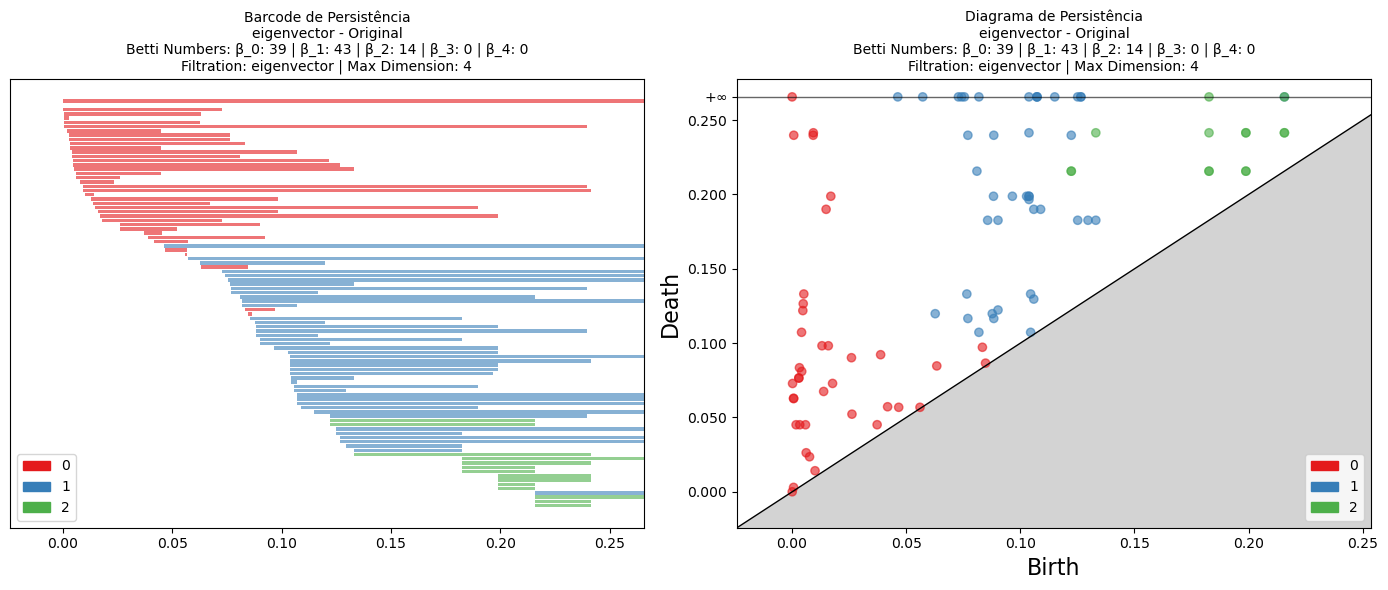

 TDA saved info: barcode_original_eigenvector.png
 Original CNN: original_eigenvector.png
 Original TDA: barcode_original_eigenvector.png

Starting systematic node removal and TDA computation for measure: EIGENVECTOR
  node 1/162: SETD1A
Network plot saved: without_SETD1A_eigenvector.png
 TDA saved info: barcode_without_SETD1A_eigenvector.png
  TDA saved: barcode_without_SETD1A_eigenvector.png
  node 2/162: ASH2L
Network plot saved: without_ASH2L_eigenvector.png
 TDA saved info: barcode_without_ASH2L_eigenvector.png
  TDA saved: barcode_without_ASH2L_eigenvector.png
  node 3/162: EP300
Network plot saved: without_EP300_eigenvector.png
 TDA saved info: barcode_without_EP300_eigenvector.png
  TDA saved: barcode_without_EP300_eigenvector.png
  node 4/162: HDAC1
Network plot saved: without_HDAC1_eigenvector.png
 TDA saved info: barcode_without_HDAC1_eigenvector.png
  TDA saved: barcode_without_HDAC1_eigenvector.png
  node 5/162: KAT2B
Network plot saved: without_KAT2B_eigenvector.png
 TDA 

In [6]:
CNN_Original = CCNs['CO']  # choose one network to work with, e.g., 'CO', 'DN', or 'PCD'

for measure_idx, measure in enumerate(CENTRALITY_MEASURES):
    print(f"\n{'='*60}")
    print(f"Measure: {measure.upper()}")
    print(f"{'='*60}")

    # 1. Dinamically create directories for this measure 
    basePath = Path("output")
    measure_dir = basePath / measure
    redes_dir = measure_dir / "Network-VFB"
    tda_dir = measure_dir / "Barcodes-VFB"
    tables_dir = measure_dir / "Comparative Tables"
    
    redes_dir.mkdir(parents=True, exist_ok=True)
    tda_dir.mkdir(parents=True, exist_ok=True)
    tables_dir.mkdir(parents=True, exist_ok=True)


    # 2. Centrality Measure for the complete CNN - i.e baseline
    centrality_original = get_centrality(CNN_Original, measure=measure)
    
    ranking_df = pd.DataFrame(
        sorted(centrality_original.items(), key=lambda x: x[1], reverse=True),
        columns=['Gene', f'{measure}_centrality'])
    
    ranking_df.to_csv(
        tables_dir / f"ranking_{measure}.csv",
        index=False
    )
    print(f"Ranking saved: ranking_{measure}.csv (Top {len(ranking_df)} genes)")
    print(f" TOP 50: {ranking_df['Gene'].iloc[:50].tolist()}")

    # 3. Compute TDA for the original network (baseline)
    res_original, persistence_original = compute_tda(
        CNN_Original, centrality_original, MAX_DIM, f"{measure}_sublevel"
    )
    # 3.1 Create and save visualizations for the original network and its TDA results
    if res_original:
        # Original CCNs
        orig_graph_path = os.path.join(redes_dir, f"original_{measure}.png")
        if measure_idx == 0:
            plot_network_visualization(CNN_Original, orig_graph_path, name=f"Original - {measure}", show=True)
        else:
            plot_network_visualization(CNN_Original, orig_graph_path, name=f"Original - {measure}", show=False)

        # Barcode/diagram
        orig_tda_path = os.path.join(tda_dir, f"barcode_original_{measure}.png")
        plot_barcode_and_diagram(
            orig_tda_path,
            persistence_original, 
            betti_numbers={f'Betti {dim}': res_original[f'Betti {dim}'] for dim in range(MAX_DIM + 1)},           
            title_prefix=f"{measure} - Original",
            filtration_name=measure,
            show=True)

        print(f" Original CNN: original_{measure}.png")
        print(f" Original TDA: barcode_original_{measure}.png")


    # 4. Systematic Node Removal and TDA Computation for each node in the original network
    print(f"\nStarting systematic node removal and TDA computation for measure: {measure.upper()}")

    results_log = []

    # 4.1 Baseline log row for this measure (original network without any node removed)
    baseline_row = {
        'Gene_Removed': 'ORIGINAL',
        'Node': CNN_Original.number_of_nodes(),
        **{f'Betti_{dim}': res_original[f'Betti {dim}'] for dim in range(MAX_DIM + 1)}
    }
    results_log.append(baseline_row)

    nodes_to_process = list(CNN_Original.nodes())    

    for node_idx, node in enumerate(nodes_to_process):
        print(f"  node {node_idx+1}/{len(nodes_to_process)}: {node}")

        # Removing node
        G_perturbed = CNN_Original.copy()
        G_perturbed.remove_node(node)        

        centrality_dynamic = get_centrality(G_perturbed, measure=measure)
        res_dynamic, persistence_dynamic = compute_tda(
            G_perturbed, centrality_dynamic, MAX_DIM, measure
        )
        if res_dynamic:  # Check if TDA computation was successful

            # 4.2 Network Visualization 
            graph_path = os.path.join(redes_dir, f"without_{node}_{measure}.png")
            plot_network_visualization(G_perturbed, graph_path, name=f"Without {node} - {measure}")
            print(f"Network plot saved: without_{node}_{measure}.png")

            # 4.3 BARCODE + DIAGRAM (tda/)
            tda_path = os.path.join(tda_dir, f"barcode_without_{node}_{measure}.png")
            plot_barcode_and_diagram(
                tda_path,
                persistence_dynamic,                
                title_prefix=f"{measure} - Without {node}",
                betti_numbers={f'Betti {dim}': res_dynamic[f'Betti {dim}'] for dim in range(MAX_DIM + 1)},
                filtration_name=measure,
                max_dim=MAX_DIM)

            print(f"  TDA saved: barcode_without_{node}_{measure}.png")

            # 4.4 LOG Betti
            row = {
                'Gene_Removed': node,
                'Node': G_perturbed.number_of_nodes(),
                **{f'Betti_{dim}': res_dynamic[f'Betti {dim}'] for dim in range(MAX_DIM + 1)}
            }
            results_log.append(row)

        # Nodes cleanup for memory management
        del G_perturbed, centrality_dynamic, res_dynamic
        if 'persistence_dynamic' in locals():
            del persistence_dynamic



    # 5. SAVING RESULTS FOR THIS MEASURE
    pd.DataFrame(results_log).to_csv(
        os.path.join(tables_dir, f"betti_{measure}.csv"), index=False
    )
    print(f"CSV saved: tables/betti_{measure}.csv")

    df_results = pd.DataFrame(results_log)

    # 6. FINAL CLEANUP FOR THIS MEASURE
    del centrality_original, res_original, persistence_original, results_log
    gc.collect()
    print(f"Memória limpa após {measure}. Próxima medida...")


print("All Measures Completed!") 
print(f"Results in: {basePath}")